In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import Parameter as TorchParam
from torch import Tensor
from typing import List, Tuple, Type
import random
import math

device = torch.device("cpu")
print(device)
print(torch.__version__)

cpu
2.5.1


# STNN-ERs PyTorch

This notebook is organized as a two-stage pipeline on the target motor dataset:
1. fine-tune a pretrained shared-node thermal neural network (STNN) on two shared nodes (stator and rotor) temperatures;
2. reuse those TNN predictions as inputs for a residual model that corrects the extend-node temperatures.


## 1. Data Preparation

In [71]:
class DataSet:

    input_cols = []
    target_cols = []
    dataset_path = None
    input_temperature_cols = []
    pid = "Not_Available"
    temperature_scale = 200  # in °C
    black_list = []

    def __init__(self, input_cols=None, target_cols=None, black_list=None):
        input_cols = input_cols or self.input_cols
        target_cols = target_cols or self.target_cols
        black_list = black_list or self.black_list
        self.data = pd.read_csv(self.dataset_path)
        self.input_cols = [c for c in input_cols if c in self.data]
        self.target_cols = [c for c in target_cols if c in self.data]

    @property
    def temperature_cols(self):
        return self.input_temperature_cols + self.target_cols

    @property
    def non_temperature_cols(self):
        return [c for c in self.data
                if c not in self.temperature_cols + [self.pid, 'train_'+self.pid]]

    def get_pid_sizes(self, pid_lbl=None):
        """Returns pid size as pandas Series"""
        pid_lbl = pid_lbl or self.pid
        return self.data.groupby(pid_lbl)\
                        .agg('size').sort_values(ascending=False)

    def normalize(self, method='simple'):

        nt_cols = [c for c in self.non_temperature_cols if c in self.data]
        t_cols = [c for c in self.temperature_cols if c in self.data]
        self.data.loc[:, t_cols] = (self.data.loc[:, t_cols] / self.temperature_scale)
        if method == 'simple':
            max_values = self.data.loc[:, nt_cols].abs().max(axis=0)
            self.data.loc[:, nt_cols] = (
                self.data.loc[:, nt_cols] / max_values
            )
        elif method == 'minmax':
            min_vals = self.data.loc[:, nt_cols].min(axis=0)
            max_vals = self.data.loc[:, nt_cols].max(axis=0)
            self.data.loc[:, nt_cols] = (
                (self.data.loc[:, nt_cols] - min_vals) / (max_vals - min_vals)
            )
        elif method =='zscore':
            mean_vals = self.data.loc[:, nt_cols].mean(axis=0)
            std_vals = self.data.loc[:, nt_cols].std(axis=0)
            self.data.loc[:, nt_cols] = (
                (self.data.loc[:, nt_cols] - mean_vals) / std_vals
            )
        else:
            raise ValueError("Invalid normalization method. Choose 'simple', 'minmax', or 'zscore'.")

class TestMotorDataSet(DataSet):

    input_cols = ['ambient', 'water_outlet', 'Ud', 'Uq', 'speed', 'IdRef', 'IqRef']
    target_cols = ['rotor']
    input_temperature_cols = ['ambient', 'water_outlet']
    # The following path might need to be replaced by the path on your system
    dataset_path = Path().cwd() / "dataset" / "target_data.csv"
    pid = "id"
    name = "TestIPMSM"
    sample_time = 1  # in seconds
    black_list = []

    def get_profiles(self):
        pid_sizes = self.get_pid_sizes()
        test_profiles = [8]
        val_profiles = [3]
        train_profiles = [p for p in pid_sizes.index.tolist()
                              if p not in test_profiles + val_profiles]
        return train_profiles, val_profiles, test_profiles
    

    def featurize(self, feature_strategy='basic'):
        # extra feats (FE)
        # it is highly advisable to call featurize and then normalize, not the other way around!
        # Because featurize might mess with input and target cols

        w10, w11, w20, w21 = 0.2, 0.2, 0.2, 0.2
        add_target_cols = ['stator']
        # Build a shared stator target
        self.data['stator'] = w10 * self.data['activewind'] + w11 * self.data['endwind'] + w20 * self.data['slotbottom'] + w21 * self.data['slotside'] + (1-w10-w11-w20-w21) * self.data['slotopen']
        self.target_cols = [c for c in self.data if c in self.target_cols] + add_target_cols
        col_arrangement = self.input_cols + [self.pid] + self.target_cols
        self.data = self.data.loc[:, [c for c in col_arrangement if c in self.data]]

        if {'IdRef', 'IqRef', 'Ud', 'Uq', 'speed'}.issubset(set(self.data.columns.tolist())):
            basic_feats = {
                'IsRef': lambda x: np.sqrt(x['IdRef']**2 + x['IqRef']**2),
                'Us': lambda x: np.sqrt(x['Ud']**2 + x['Uq']**2)
            }
            extensive_feats = {
                'S_el': lambda x: (x['IsRef'] * x['Us']),
                'n_i_s': lambda x: (x['speed'] * x['IsRef']),
                'n_S_el': lambda x: (x['speed'] * x['IsRef'] * x['Us'])
            }
            if feature_strategy == 'plain':
                extra_feats = {}
            elif feature_strategy == 'basic':
                extra_feats = basic_feats
            elif feature_strategy == 'extensive':
                # add basic feats first, so that they are available for extensive feats
                self.data = self.data.assign(**basic_feats)
                extra_feats = extensive_feats
            else:
                raise ValueError(f'Unknown feature_strategy: {feature_strategy}')
            self.data = self.data.assign(**extra_feats)
        
        self.input_cols = [
            c for c in self.data if c not in self.target_cols + [self.pid]]
        # rearrange
        self.data = self.data.loc[:, self.input_cols +
                                  [self.pid] + self.target_cols]
        
    def plot_profiles(self, profile_ids=None, ncols=3):
        """Plot speed and torque profiles for given profile IDs
        
        Args:
            profile_ids: List of profile IDs to plot. If None, plots all profiles
            ncols: Number of columns in the subplot grid
        """
        if profile_ids is None:
            profile_ids = self.data[self.pid].unique()
        
        nrows = math.ceil(len(profile_ids) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
        axes = np.array(axes).reshape(-1)
        
        for ax, pid in zip(axes, profile_ids):
            g = self.data[self.data[self.pid] == pid].reset_index(drop=True)
            t = np.arange(len(g))
            
            ax.plot(t, g["speed"], color="blue", label="speed")
            ax.set_title(f"id = {pid}")
            ax.set_xlabel("time")
            ax.set_ylabel("speed", color="blue")
            ax.tick_params(axis="y", labelcolor="blue")
            ax.grid(alpha=0.3)
            
            ax2 = ax.twinx()
            ax2.plot(t, g["torque"], color="red", label="torque")
            ax2.set_ylabel("torque", color="red")
            ax2.tick_params(axis="y", labelcolor="red")
        
        for ax in axes[len(profile_ids):]:
            ax.set_visible(False)
        
        plt.tight_layout()
        plt.show()

In [72]:
def generate_tensor(profiles_list, _ds, device, pid_lbl=None):
    """Returns profiles of the data set in a coherent 3D tensor with
    time-major shape (T, B, F) where
    T : Maximum profile length
    B : Batch size = Amount of profiles
    F : Amount of input features.

    Also returns a likewise-shaped sample_weights tensor, which zeros out post-padded zeros for use
    in the cost function (i.e., it acts as masking tensor)"""
    pid_lbl = pid_lbl or _ds.pid
    tensor = np.full(
        (_ds.get_pid_sizes(pid_lbl)[profiles_list].max(),
         len(profiles_list), _ds.data.shape[1] - 1),np.nan,)
    
    for i, (pid, df) in enumerate(_ds.data.loc[_ds.data.loc[:, pid_lbl].isin(profiles_list), :]
                                          .groupby(pid_lbl)):
        tensor[ :len(df), i, :] = df.drop(columns=pid_lbl).to_numpy()
    sample_weights = 1 - np.isnan(tensor[:, :, 0])
    tensor = np.nan_to_num(tensor).astype(np.float32)
    tensor = torch.from_numpy(tensor).to(device)
    sample_weights = torch.from_numpy(sample_weights).to(device)
    return tensor, sample_weights

## 2. Base TNN Definition

In [73]:
class DiffEqLayer(nn.Module):
    """This class is a container for the computation logic in each step.
    This layer could be used for any 'cell', also RNNs, LSTMs or GRUs."""

    def __init__(self, cell, *cell_args, **cell_kwargs):
        super().__init__()
        self.cell = cell(*cell_args, **cell_kwargs)

    def forward(self, input: Tensor, state: Tensor) -> Tuple[Tensor, Tensor]:
        inputs = input.unbind(0)
        outputs = torch.jit.annotate(List[Tensor], [])
        for i in range(len(inputs)):
            out, state = self.cell(inputs[i], state)
            outputs += [out]
        return torch.stack(outputs), state
    
# Integral power loss is modeled separately for each output temperature.
# In other words, every target node gets its own small power-loss sub-network.

class TNNCell(nn.Module):
    """The main TNN logic. Here, the sub-NNs are initialized as well as the constant learnable
    thermal capacitances. The forward function houses the LPTN ODE discretized with the explicit Euler method
    """

    def __init__(self, _ds, device, caps_mean=[-9.3], caps_std=[0.5],
                 conductance_hidden_dims: List[int] = [],
                 conductance_activations: List[Type[nn.Module]] = [],
                 ploss_hidden_dims: List[int] = [],
                 ploss_activations: List[Type[nn.Module]] = []):
        super().__init__()
        self.sample_time = _ds.sample_time  # in s
        self.output_size = len(_ds.target_cols)

        if len(caps_mean) == 1:
            caps_mean = caps_mean * self.output_size
        if len(caps_std) == 1:
            caps_std = caps_std * self.output_size
        assert len(caps_mean) == self.output_size, "caps_mean length must match output_size"
        assert len(caps_std) == self.output_size, "caps_std length must match output_size"

        self.caps = TorchParam(torch.Tensor(self.output_size).to(device))
        for i in range(self.output_size):
            nn.init.normal_(self.caps[i:i+1], mean=caps_mean[i], std=caps_std[i])
        
        n_temps = len(_ds.temperature_cols)  # number of temperatures (targets and input)
        n_conds = int(0.5 * n_temps * (n_temps - 1))  # number of thermal conductances
        
        # conductance net sub-NN
        conduct_layers = []
        input_dim = len(_ds.input_cols) + self.output_size
        num_layers = len(conductance_hidden_dims)

        for i in range(num_layers):
            hidden_dim = conductance_hidden_dims[i]
            conduct_layers.append(nn.Linear(input_dim, hidden_dim))
            if i < len(conductance_activations):
                activation = conductance_activations[i]
                conduct_layers.append(activation())
            input_dim = hidden_dim

        conduct_layers.append(nn.Linear(input_dim, n_conds))
        if conductance_activations and callable(conductance_activations[-1]):
            conduct_layers.append(conductance_activations[-1]())

        if not conduct_layers:
            activation = conductance_activations[0] if conductance_activations else nn.Sigmoid
            conduct_layers = [nn.Linear(len(_ds.input_cols) + self.output_size, n_conds),
                              activation()]
            
        self.conductance_net = nn.Sequential(*conduct_layers)

        
        # populate adjacency matrix. It is used for indexing the conductance sub-NN output
        self.adj_mat = np.zeros((n_temps, n_temps), dtype=int)
        adj_idx_arr = np.ones_like(self.adj_mat)
        triu_idx = np.triu_indices(n_temps, 1)
        adj_idx_arr = adj_idx_arr[triu_idx].ravel()
        self.adj_mat[triu_idx] = np.cumsum(adj_idx_arr) - 1
        self.adj_mat += self.adj_mat.T
        self.adj_mat = torch.from_numpy(self.adj_mat[: self.output_size, :]).type(
            torch.int64
        )  # crop
        self.n_temps = n_temps
        # One power-loss head per predicted temperature.
        self.ploss_nets = nn.ModuleList()
        ploss_input_dim = len(_ds.input_cols) + self.output_size
        
        for _ in range(self.output_size):
            ploss_layers = []
            current_dim = ploss_input_dim
            
            for hidden_dim in ploss_hidden_dims:
                ploss_layers.append(nn.Linear(current_dim, hidden_dim))
                if ploss_activations:
                    activation = ploss_activations[0] if len(ploss_activations) == 1 else ploss_activations[len(ploss_layers)//2]
                    ploss_layers.append(activation())
                current_dim = hidden_dim
            
            ploss_layers.append(nn.Linear(current_dim, 1))
            
            self.ploss_nets.append(nn.Sequential(*ploss_layers))
        
        self.temp_idcs = [i for i, x in enumerate(_ds.input_cols) if x in _ds.temperature_cols]
        self.nontemp_idcs = [
            i
            for i, x in enumerate(_ds.input_cols)
            if x not in _ds.temperature_cols + [_ds.pid]
        ]

    def forward(self, inp: Tensor, hidden: Tensor) -> Tuple[Tensor, Tensor]:
        prev_out = hidden
        temps = torch.cat([prev_out, inp[:, self.temp_idcs]], dim=1)
        sub_nn_inp = torch.cat([inp, prev_out], dim=1)
        conducts = torch.abs(self.conductance_net(sub_nn_inp))
        
        power_losses = []
        for i, net in enumerate(self.ploss_nets):
            ploss_out = net(sub_nn_inp)
            power_losses.append(torch.abs(ploss_out))
        
        power_loss = torch.cat(power_losses, dim=1)
        
        temp_diffs = torch.sum(
            (temps.unsqueeze(1) - prev_out.unsqueeze(-1)) * conducts[:, self.adj_mat],
            dim=-1,
        )
        out = prev_out + self.sample_time * torch.exp(self.caps) * (
            temp_diffs + power_loss
        )
        return prev_out, torch.clip(out, -1, 5)


In [74]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

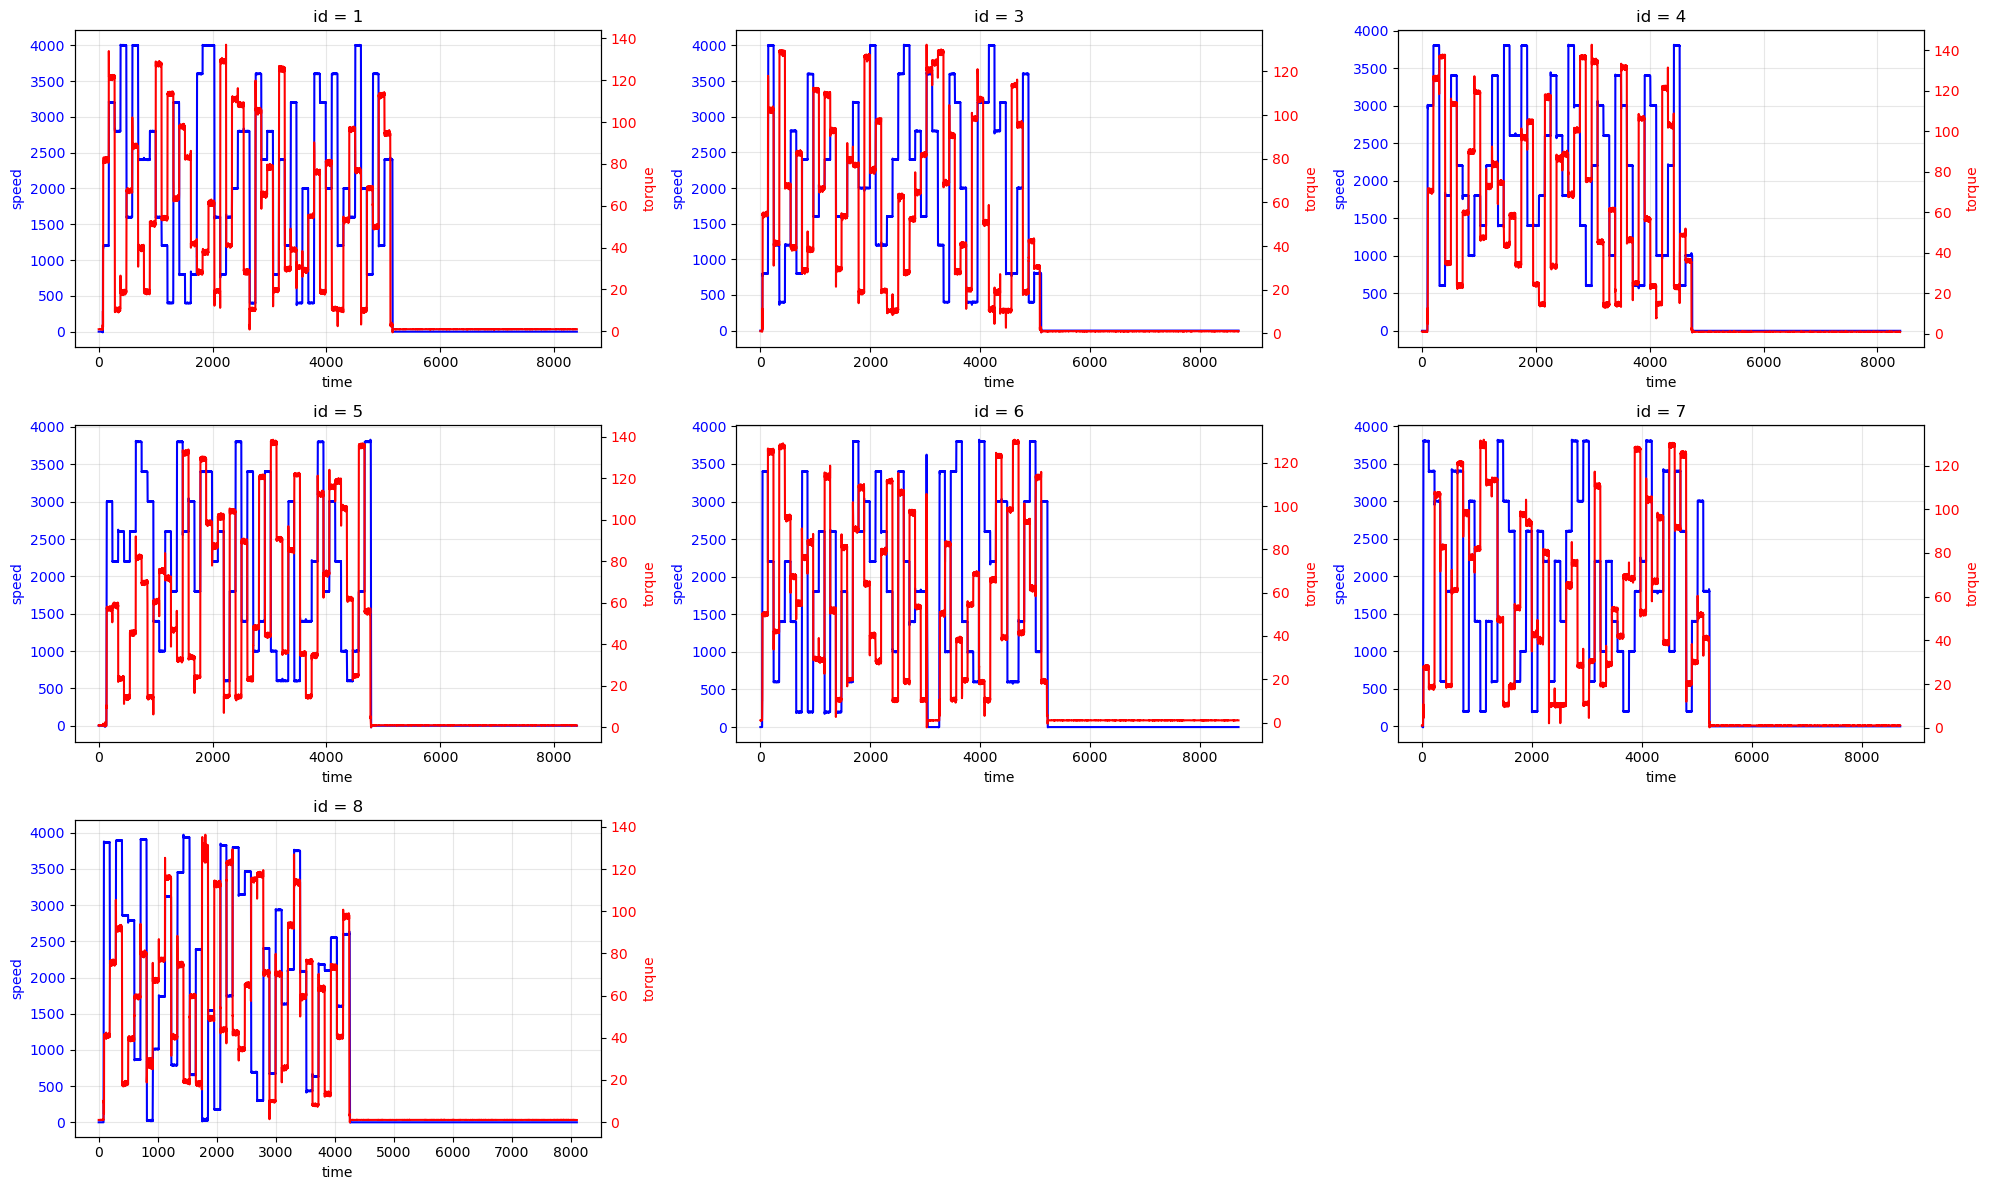

In [75]:
ds = TestMotorDataSet()
ds.plot_profiles()
ds.featurize()
ds.normalize()

In [76]:
print(len(ds.input_cols), ds.input_cols)
print(len(ds.target_cols), ds.target_cols)
print(ds.temperature_cols)
print(ds.non_temperature_cols)
print(ds.pid)

9 ['ambient', 'water_outlet', 'Ud', 'Uq', 'speed', 'IdRef', 'IqRef', 'IsRef', 'Us']
2 ['rotor', 'stator']
['ambient', 'water_outlet', 'rotor', 'stator']
['Ud', 'Uq', 'speed', 'IdRef', 'IqRef', 'IsRef', 'Us']
id


In [77]:
print(ds.data.head(5))
print(ds.data.shape)

   ambient  water_outlet        Ud        Uq  speed  IdRef  IqRef  IsRef  \
0  0.09845        0.1235 -0.001611  0.000376    0.0    0.0    0.0    0.0   
1  0.09865        0.1235  0.001424  0.000131    0.0    0.0    0.0    0.0   
2  0.09865        0.1235 -0.000458  0.002095    0.0    0.0    0.0    0.0   
3  0.09895        0.1235 -0.001183  0.002008    0.0    0.0    0.0    0.0   
4  0.09925        0.1235  0.002244  0.002014    0.0    0.0    0.0    0.0   

         Us  id     rotor    stator  
0  0.001468   1  0.124233  0.127895  
1  0.001286   1  0.124238  0.127915  
2  0.001295   1  0.124241  0.127915  
3  0.001587   1  0.124356  0.127915  
4  0.002341   1  0.124458  0.127925  
(59400, 12)


In [78]:
train_profiles, val_profiles, test_profiles = ds.get_profiles()
train_tensor, train_sample_weights = generate_tensor(train_profiles, ds, device)
val_tensor, val_sample_weights = generate_tensor(val_profiles, ds, device)
test_tensor, test_sample_weights = generate_tensor(test_profiles, ds, device)

In [36]:
# Load the pretrained model for fine-tuning
mdl_path = Path.cwd() / 'model'
mdl_path.mkdir(exist_ok=True, parents=True)
mdl_file_path = mdl_path / 'stnn_pretrain.pt'
model = torch.jit.load(mdl_file_path)

## 3. Fine-Tune the Pretrained TNN

In [40]:
SEED = 4
set_seed(SEED)

# Uncomment the block below to train the TNN from scratch instead of loading
# the TorchScript checkpoint from ./model/stnn_pretrain.pt.
# model = torch.jit.script(DiffEqLayer(TNNCell,
#                                      ds,
#                                      device,
#                                      conductance_hidden_dims=[],
#                                      conductance_activations=[nn.Sigmoid],
#                                      ploss_hidden_dims=[16, 8],
#                                      ploss_activations=[nn.Tanh, nn.ReLU]
#                                      ).to(device))

print(model)
loss_func = nn.MSELoss(reduction="none")
opt = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.8, patience=10)
n_epochs = 300
tbptt_size = 128
patience = 50
n_batches = np.ceil(train_tensor.shape[0] / tbptt_size).astype(int)
val_n_batches = np.ceil(val_tensor.shape[0] / tbptt_size).astype(int)

RecursiveScriptModule(
  original_name=DiffEqLayer
  (cell): RecursiveScriptModule(
    original_name=TNNCell
    (conductance_net): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(original_name=Linear)
      (1): RecursiveScriptModule(original_name=Sigmoid)
    )
    (ploss_nets): RecursiveScriptModule(
      original_name=ModuleList
      (0): RecursiveScriptModule(
        original_name=Sequential
        (0): RecursiveScriptModule(original_name=Linear)
        (1): RecursiveScriptModule(original_name=Tanh)
        (2): RecursiveScriptModule(original_name=Linear)
        (3): RecursiveScriptModule(original_name=ReLU)
        (4): RecursiveScriptModule(original_name=Linear)
      )
      (1): RecursiveScriptModule(
        original_name=Sequential
        (0): RecursiveScriptModule(original_name=Linear)
        (1): RecursiveScriptModule(original_name=Tanh)
        (2): RecursiveScriptModule(original_name=Linear)
        (3): RecursiveScriptModu

In [41]:
best_val_loss = float('inf')
epochs_no_improve = 0
history = {"train": [], "val": [], "lr": []}

with tqdm(desc="Training", total=n_epochs) as pbar:
    for epoch in range(n_epochs):
        # Initialize each profile with its first observed target temperature.
        hidden = train_tensor[0, :, -len(ds.target_cols) :]
        model.train()
        train_batch_losses = []
        for i in range(n_batches):
            start = i * tbptt_size
            end = min((i + 1) * tbptt_size, train_tensor.shape[0])
            input_batch = train_tensor[start:end, :, : len(ds.input_cols)]
            target_batch = train_tensor[start:end, :, -len(ds.target_cols) :]

            model.zero_grad()
            output, hidden = model(input_batch, hidden.detach())
            mask_hidden = train_sample_weights[end - 1, :].float()
            hidden = hidden * mask_hidden[:, None]

            loss = loss_func(output, target_batch)
            # sample_weighting
            loss = (
                (
                    loss * train_sample_weights[start:end, :, None]
                    / train_sample_weights[start:end, :]
                    .sum()
                )
                .sum()
                .mean()
            )
            
            train_batch_losses.append(loss.item())
            loss.backward()
            opt.step()

        avg_train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
        
        model.eval()
        val_hidden = val_tensor[0, :, -len(ds.target_cols) :]
        with torch.no_grad():
            val_losses = []
            for i in range(val_n_batches):
                val_output, val_hidden = model(
                    val_tensor[
                        i * tbptt_size : (i + 1) * tbptt_size, :, : len(ds.input_cols)
                    ],
                    val_hidden,
                )
                
                val_loss = loss_func(
                    val_output,
                    val_tensor[
                        i * tbptt_size : (i + 1) * tbptt_size, :, -len(ds.target_cols) :
                    ],
                )
                val_loss = (
                    (
                        val_loss
                        * val_sample_weights[
                            i * tbptt_size : (i + 1) * tbptt_size, :, None
                        ]
                        / val_sample_weights[
                            i * tbptt_size : (i + 1) * tbptt_size, :
                        ].sum()
                    )
                    .sum()
                    .mean()
                )
                
                val_losses.append(val_loss.item())
        avg_val_loss = sum(val_losses) / len(val_losses)
        scheduler.step(avg_val_loss)
        
        history["train"].append(avg_train_batch_loss)
        history["val"].append(avg_val_loss)
        history["lr"].append(opt.param_groups[0]["lr"])

        # early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        pbar.update()
        pbar.set_postfix_str(f"loss: {avg_train_batch_loss:.2e}, val_loss: {avg_val_loss:.2e}")

Training: 100%|██████████| 300/300 [24:05<00:00,  4.82s/it, loss: 5.04e-05, val_loss: 4.84e-05]


In [42]:
model.eval()
with torch.no_grad():
    pred, hidden = model(
        test_tensor[:, :, : len(ds.input_cols)], test_tensor[0, :, -len(ds.target_cols) :]
    )
    pred = pred.cpu().numpy() * 200  # denormalize

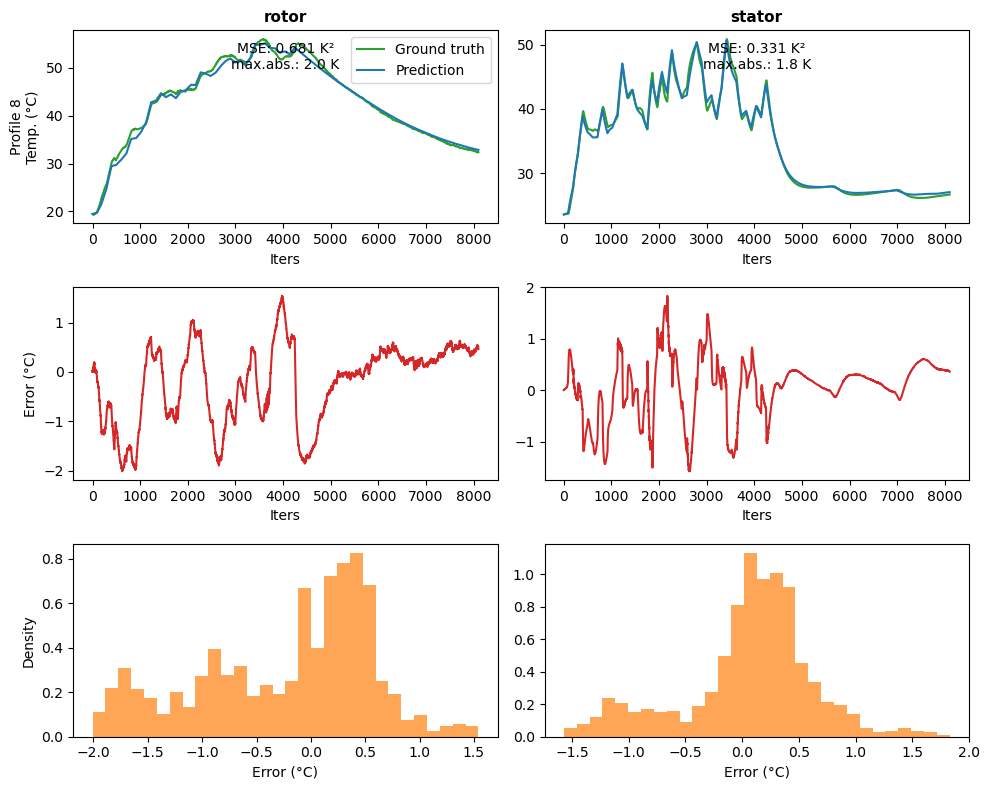

In [43]:
fig, axes = plt.subplots(len(test_profiles) * 3, len(ds.target_cols), figsize=(10, 8))

if axes.ndim == 1:
    axes = axes.reshape(len(test_profiles) * 3, len(ds.target_cols))

mse_stats = []
max_abs_stats = []

test_df = ds.data.loc[ds.data.id.isin(test_profiles), ds.target_cols + [ds.pid]]

for i, (pid, y_test) in enumerate(test_df.groupby(ds.pid)):
    y_true = y_test.loc[:, ds.target_cols].reset_index(drop=True) * 200
    profile_pred = pred[:len(y_true), i, :]

    profile_mse = {"profile_id": pid}
    profile_max_abs = {"profile_id": pid}

    for j, col in enumerate(ds.target_cols):
        error = profile_pred[:, j] - y_true[col].values
        mse = np.mean(error ** 2)
        max_abs = np.max(np.abs(error))

        profile_mse[col] = mse
        profile_max_abs[col] = max_abs

        ax_original = axes[i * 3, j]
        ax_original.plot(y_true[col].values, color="tab:green", label="Ground truth")
        ax_original.plot(profile_pred[:, j], color="tab:blue", label="Prediction")
        ax_original.text(
            0.5,
            0.8,
            f"MSE: {mse:.3f} K²\nmax.abs.: {max_abs:.1f} K",
            transform=ax_original.transAxes,
            ha="center",
        )
        if i == 0:
            ax_original.set_title(col, fontsize=11, fontweight="bold")
        if j == 0:
            ax_original.set_ylabel(f"Profile {pid}\nTemp. (°C)")
            ax_original.legend()
        if i == len(test_profiles) - 1:
            ax_original.set_xlabel("Iters")

        ax_error = axes[i * 3 + 1, j]
        ax_error.plot(error, color="tab:red")
        if j == 0:
            ax_error.set_ylabel("Error (°C)")
        if i == len(test_profiles) - 1:
            ax_error.set_xlabel("Iters")

        ax_pdf = axes[i * 3 + 2, j]
        ax_pdf.hist(error, bins=30, density=True, color="tab:orange", alpha=0.7)
        if j == 0:
            ax_pdf.set_ylabel("Density")
        if i == len(test_profiles) - 1:
            ax_pdf.set_xlabel("Error (°C)")

    mse_stats.append(profile_mse)
    max_abs_stats.append(profile_max_abs)

plt.tight_layout()
plt.show()

## 4. Build the Residual-Learning Dataset

In [ ]:
class ResidualMotorDataSet(DataSet):

    input_cols = ['ambient', 'water_outlet', 'Ud', 'Uq', 'speed', 'IdRef', 'IqRef', 'IsRef', 'Us', 'pred_stator', 'pred_rotor']
    target_cols = ['slotbottom', 'slotside', 'slotopen', 'activewind', 'endwind']
    input_temperature_cols = ['ambient', 'water_outlet', 'pred_stator', 'pred_rotor']
    # The following path might need to be replaced by the path on your system
    dataset_path = Path().cwd() / "dataset" / "target_data.csv"
    pid = "id"
    name = "TestIPMSM"
    sample_time = 1  # in seconds
    black_list = []

    def get_profiles(self):
        pid_sizes = self.get_pid_sizes()
        test_profiles = [8]
        val_profiles = [3]
        train_profiles = [p for p in pid_sizes.index.tolist()
                              if p not in test_profiles + val_profiles]
        return train_profiles, val_profiles, test_profiles

    def featurize(self, feature_strategy='basic'):
        # extra feats (FE)
        # it is highly advisable to call featurize and then normalize, not the other way around!
        # Because featurize might mess with input and target cols

        col_arrangement = self.input_cols + [self.pid] + self.target_cols
        self.data = self.data.loc[:, [c for c in col_arrangement if c in self.data]]

        if {'IdRef', 'IqRef', 'Ud', 'Uq', 'speed'}.issubset(set(self.data.columns.tolist())):
            basic_feats = {
                'IsRef': lambda x: np.sqrt(x['IdRef']**2 + x['IqRef']**2),
                'Us': lambda x: np.sqrt(x['Ud']**2 + x['Uq']**2)
            }
            extensive_feats = {
                'S_el': lambda x: (x['IsRef'] * x['Us']),
                #'P_el': lambda x: x['i_d'] * x['u_d'] + x['i_q'] * x['u_q'],
                'n_i_s': lambda x: (x['speed'] * x['IsRef']),
                'n_S_el': lambda x: (x['speed'] * x['IsRef'] * x['Us'])
            }
            if feature_strategy == 'plain':
                extra_feats = {}
            elif feature_strategy == 'basic':
                extra_feats = basic_feats
            elif feature_strategy == 'extensive':
                # add basic feats first, so that they are available for extensive feats
                self.data = self.data.assign(**basic_feats)
                extra_feats = extensive_feats
            else:
                raise ValueError(f'Unknown feature_strategy: {feature_strategy}')
            self.data = self.data.assign(**extra_feats)
        self.input_cols = [
            c for c in self.data if c not in self.target_cols + [self.pid]]
        
        # rearrange
        self.data = self.data.loc[:, self.input_cols +
                                  [self.pid] + self.target_cols]

# ERs description

In [52]:
class DeltaHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

class StatorDeltaNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=8):
        super().__init__()
        self.heads = nn.ModuleList(
            [DeltaHead(input_dim, hidden_dim) for _ in range(output_dim)]
        )

    def forward(self, x, stator_pred):
        deltas = torch.cat([head(x) for head in self.heads], dim=2)
        return stator_pred.expand_as(deltas) + deltas


In [53]:
ds = ResidualMotorDataSet()
ds.featurize()
ds.normalize()

In [54]:
input_order = ['ambient', 'water_outlet', 'Ud', 'Uq', 'speed', 'IdRef', 
               'IqRef', 'IsRef', 'Us', 'pred_stator', 'pred_rotor',]
ds.input_cols = [c for c in input_order if c in ds.data.columns]
ds.target_cols = [c for c in ds.target_cols if c in ds.data.columns]
ds.data = ds.data.loc[:, ds.input_cols + [ds.pid] + ds.target_cols]
stator_pred_idx = ds.data.columns.get_loc('pred_stator')
ds.data.head(5)

,ambient,water_outlet,Ud,Uq,speed,IdRef,IqRef,IsRef,Us,pred_stator,pred_rotor,id,slotbottom,slotside,slotopen,activewind,endwind
0,0.09845,0.1235,-0.001611,0.000376,0.0,0.0,0.0,0.0,0.001468,0.127895,0.124233,1,0.12715,0.12705,0.12980,0.127850,0.127625
1,0.09865,0.1235,0.001424,0.000131,0.0,0.0,0.0,0.0,0.001286,0.127905,0.124238,1,0.12720,0.12705,0.12980,0.127875,0.127650
2,0.09865,0.1235,-0.000458,0.002095,0.0,0.0,0.0,0.0,0.001295,0.127915,0.124242,1,0.12720,0.12705,0.12980,0.127875,0.127650
3,0.09895,0.1235,-0.001183,0.002008,0.0,0.0,0.0,0.0,0.001587,0.127925,0.124246,1,0.12720,0.12705,0.12980,0.127875,0.127650
4,0.09925,0.1235,0.002244,0.002014,0.0,0.0,0.0,0.0,0.002341,0.127936,0.124251,1,0.12720,0.12705,0.12985,0.127875,0.127650


In [55]:
print(len(ds.input_cols), ds.input_cols)
print(len(ds.target_cols), ds.target_cols)

11 ['ambient', 'water_outlet', 'Ud', 'Uq', 'speed', 'IdRef', 'IqRef', 'IsRef', 'Us', 'pred_stator', 'pred_rotor']
5 ['slotbottom', 'slotside', 'slotopen', 'activewind', 'endwind']


In [56]:
train_profiles, val_profiles, test_profiles = ds.get_profiles()
train_tensor, train_sample_weights = generate_tensor(train_profiles, ds, device)
print(train_profiles)
val_tensor, val_sample_weights = generate_tensor(val_profiles, ds, device)
test_tensor, test_sample_weights = generate_tensor(test_profiles, ds, device)


[6, 7, 1, 4, 5]


In [57]:
SEED = 4
set_seed(SEED)
model = StatorDeltaNetwork(len(ds.input_cols), len(ds.target_cols)).to(device)
loss_func = nn.MSELoss(reduction="none")
opt = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.8, patience=10
)
n_epochs = 300
tbptt_size = 128
patience = 50
n_batches = np.ceil(train_tensor.shape[0] / tbptt_size).astype(int)
val_n_batches = np.ceil(val_tensor.shape[0] / tbptt_size).astype(int)

In [58]:
print(model)

StatorDeltaNetwork(
  (heads): ModuleList(
    (0-4): 5 x DeltaHead(
      (net): Sequential(
        (0): Linear(in_features=11, out_features=8, bias=True)
        (1): Sigmoid()
        (2): Linear(in_features=8, out_features=1, bias=True)
      )
    )
  )
)


In [59]:
best_val_loss = float('inf')
epochs_no_improve = 0
history = {"train": [], "val": [], "lr": []}

with tqdm(desc="Training", total=n_epochs) as pbar:
    for epoch in range(n_epochs):
        model.train()
        train_batch_losses = []

        for i in range(n_batches):
            start = i * tbptt_size
            end = min((i + 1) * tbptt_size, train_tensor.shape[0])
            input_batch = train_tensor[start:end, :, : len(ds.input_cols)]
            target_batch = train_tensor[start:end, :, -len(ds.target_cols) :]
            stator_pred_batch = input_batch[:, :, stator_pred_idx:stator_pred_idx+1]

            opt.zero_grad()
            output = model(input_batch, stator_pred_batch)
            loss = loss_func(output, target_batch) 
            loss = (
                (
                    loss * train_sample_weights[start:end, :, None]
                    / train_sample_weights[start:end, :]
                    .sum()
                )
                .sum()
                .mean()
            )

            train_batch_losses.append(loss.item())
            loss.backward()
            opt.step()

        avg_train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for i in range(val_n_batches):
                val_start = i * tbptt_size
                val_end = min((i + 1) * tbptt_size, val_tensor.shape[0])
                val_input_batch = val_tensor[val_start:val_end, :, : len(ds.input_cols)]
                val_stator_pred_batch = val_input_batch[:, :, stator_pred_idx:stator_pred_idx+1]
                
                val_output = model(val_input_batch, val_stator_pred_batch)
                val_loss = loss_func(
                    val_output,
                    val_tensor[
                        i * tbptt_size : (i + 1) * tbptt_size, :, -len(ds.target_cols) :
                    ],
                )
                val_loss = (
                    (
                        val_loss
                        * val_sample_weights[
                            i * tbptt_size : (i + 1) * tbptt_size, :, None
                        ]
                        / val_sample_weights[
                            i * tbptt_size : (i + 1) * tbptt_size, :
                        ].sum()
                    )
                    .sum()
                    .mean()
                )
                
                val_losses.append(val_loss.item())
        avg_val_loss = sum(val_losses) / len(val_losses)
        
        scheduler.step(avg_val_loss)

        history["train"].append(avg_train_batch_loss)
        history["val"].append(avg_val_loss)
        history["lr"].append(opt.param_groups[0]["lr"])

        # early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        pbar.update()
        pbar.set_postfix_str(f"loss: {avg_train_batch_loss:.2e}, val_loss: {avg_val_loss:.2e}")

Training:  66%|██████▌   | 198/300 [00:36<00:18,  5.48it/s, loss: 7.57e-05, val_loss: 6.38e-05]

Early stopping at epoch 198


## 6. Evaluate the Residual Model

In [60]:
model.eval()
with torch.no_grad():
    test_input = test_tensor[:, :, : len(ds.input_cols)]
    test_stator_pred = test_input[:, :, stator_pred_idx:stator_pred_idx+1]
    pred = model(test_input, test_stator_pred)
    pred = pred.cpu().numpy() * 200  # denormalize
    

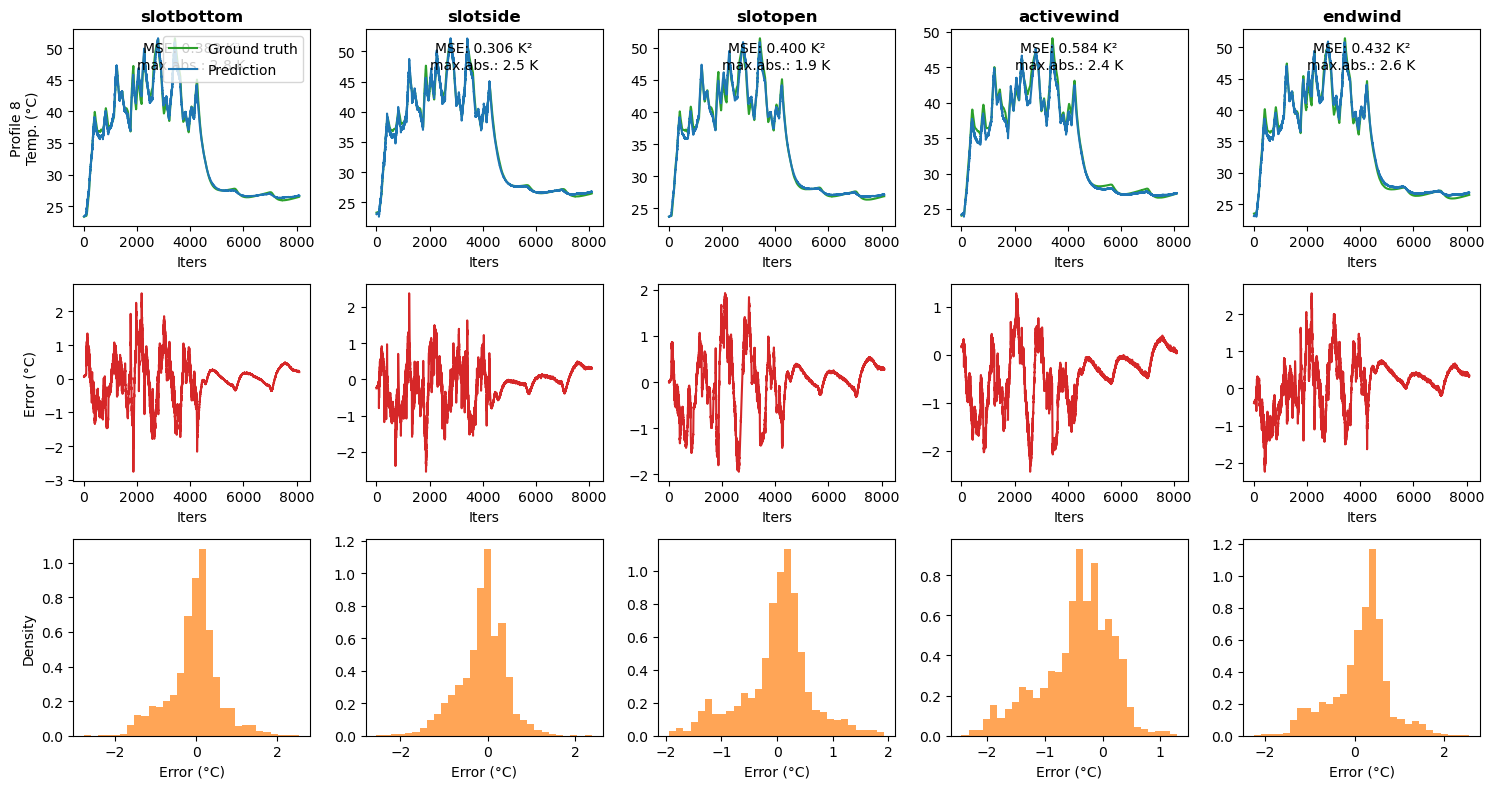

In [61]:
fig, axes = plt.subplots(len(test_profiles) * 3, len(ds.target_cols), figsize=(15, 8))

if axes.ndim == 1:
    axes = axes.reshape(len(test_profiles) * 3, len(ds.target_cols))

test_df = ds.data.loc[ds.data.id.isin(test_profiles), ds.target_cols + [ds.pid]]

for i, (pid, y_test) in enumerate(test_df.groupby(ds.pid)):
    y_true = y_test.loc[:, ds.target_cols].reset_index(drop=True) * 200
    profile_pred = pred[:len(y_true), i, :]

    for j, col in enumerate(ds.target_cols):
        mse = np.mean((profile_pred[:, j] - y_true[col].values) ** 2)
        max_abs = np.max(np.abs(profile_pred[:, j] - y_true[col].values))
        error = profile_pred[:, j] - y_true[col].values

        # 1) Ground truth vs prediction
        ax_main = axes[i * 3, j]
        ax_main.plot(y_true[col].values, color="tab:green", label="Ground truth")
        ax_main.plot(profile_pred[:, j], color="tab:blue", label="Prediction")
        ax_main.text(
            0.5, 0.8,
            f"MSE: {mse:.3f} K²\nmax.abs.: {max_abs:.1f} K",
            transform=ax_main.transAxes,
            ha="center",
        )

        if i == 0:
            ax_main.set_title(f"{col}", fontsize=12, fontweight="bold")
        if j == 0:
            ax_main.set_ylabel(f"Profile {pid}\nTemp. (°C)")
            ax_main.legend()
        if i == len(test_profiles) - 1:
            ax_main.set_xlabel("Iters")

        # 2) Error curve
        ax_err = axes[i * 3 + 1, j]
        ax_err.plot(error, color="tab:red")
        if j == 0:
            ax_err.set_ylabel("Error (°C)")
        if i == len(test_profiles) - 1:
            ax_err.set_xlabel("Iters")

        # 3) Error histogram
        ax_hist = axes[i * 3 + 2, j]
        ax_hist.hist(error, bins=30, density=True, color="tab:orange", alpha=0.7)
        if j == 0:
            ax_hist.set_ylabel("Density")
        if i == len(test_profiles) - 1:
            ax_hist.set_xlabel("Error (°C)")

plt.tight_layout()
plt.show()
